# IEEE-CIS Fraud Detection Pipeline

End-to-end fraud detection pipeline on the IEEE-CIS dataset.

**Pipeline Structure:**

| # | Section | Description |
|---|---------|-------------|
| 1 | **Setup & Data Loading** | Imports, configuration, load & merge data |
| 2 | **Feature Engineering** | Create predictive features |
| 3 | **Preprocessing** | Handle missing values & encode categoricals |
| 4 | **Modelling** | LightGBM 5-Fold Stratified CV |
| 5 | **Model Evaluation** | Metrics, curves, OOF analysis |
| 6 | **Feature Importance & SHAP** | Interpretability |
| 7 | **Model Export** | Save models as `.joblib` for deployment |

---
# 1. Setup & Data Loading
---

## 1.1 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import lightgbm as lgb
import shap
import joblib
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, precision_recall_curve, roc_curve
)

plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')
SEED = 42

print('All libraries loaded successfully.')
print(f'LightGBM version: {lgb.__version__}')

All libraries loaded successfully.
LightGBM version: 4.6.0


/Users/zhengwei/Downloads/nus/Y3S2/is4228/is4228-project---fraud-detection/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1.2 Data Loading & Merging

In [2]:
# Dynamic path resolution
DATA_DIR = Path().resolve()


train_tr = pd.read_csv("train_transaction.csv")
train_id = pd.read_csv("train_identity.csv")
test_tr  = pd.read_csv("test_transaction.csv")
test_id  = pd.read_csv("test_identity.csv")

# test_identity uses hyphens (id-01), train uses underscores (id_01)
test_id.columns = [c.replace("-", "_") for c in test_id.columns]

print("train_transaction:", train_tr.shape)
print("train_identity   :", train_id.shape)
print("test_transaction :", test_tr.shape)
print("test_identity    :", test_id.shape)

train = train_tr.merge(train_id, on="TransactionID", how="left")
test  = test_tr.merge(test_id,   on="TransactionID", how="left")

print("Merged train:", train.shape)
print("Merged test :", test.shape)
print("Fraud rate  :", round(train["isFraud"].mean() * 100, 2), "%")


train_transaction: (590540, 394)
train_identity   : (144233, 41)
test_transaction : (506691, 393)
test_identity    : (141907, 41)
Merged train: (590540, 434)
Merged test : (506691, 433)
Fraud rate  : 3.5 %


---
# 2. Feature Engineering
---

In [3]:
def feature_engineering(df):
    df = df.copy()

    # ── Time Features ────────────────────────────────────────────
    # TransactionDT is seconds offset from 2017-12-01
    START = pd.Timestamp('2017-12-01')
    dt = START + pd.to_timedelta(df['TransactionDT'], unit='s')
    df['hour']       = dt.dt.hour
    df['dayofweek']  = dt.dt.dayofweek
    df['day']        = dt.dt.day
    df['month']      = dt.dt.month
    # Whether transaction occurred at night (0–6 AM)
    df['is_night']   = (df['hour'] < 6).astype(int)
    # Whether transaction occurred on a weekend
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

    # ── Email Domain Features ────────────────────────────────────────
    for col in ['P_emaildomain', 'R_emaildomain']:
        # Extract primary domain (e.g. gmail.com → gmail)
        df[col + '_domain'] = df[col].fillna('missing').apply(
            lambda x: x.split('.')[0] if x != 'missing' else 'missing'
        )
        # Whether the email provider is mainstream
        mainstream = {'gmail', 'yahoo', 'hotmail', 'outlook', 'aol', 'icloud', 'live', 'msn'}
        df[col + '_is_mainstream'] = df[col + '_domain'].isin(mainstream).astype(int)

    # ── Transaction Amount Features ──────────────────────────────────
    df['TransactionAmt_log'] = np.log1p(df['TransactionAmt'])
    # Decimal part of the amount (fraudulent transactions often use round numbers)
    df['TransactionAmt_decimal'] = df['TransactionAmt'] - df['TransactionAmt'].astype(int)

    # ── Card Combination Features ─────────────────────────────────────
    # card1 + addr1 combo: represents the billing address for the same card
    df['card1_addr1'] = df['card1'].astype(str) + '_' + df['addr1'].astype(str)

    # ── Frequency Encoding (computed on training set to avoid data leakage) ────
    # Placeholder — frequency encoding is applied outside the training loop below

    return df

train = feature_engineering(train)
test  = feature_engineering(test)
print('Feature engineering done.')
print(f'Train shape: {train.shape}, Test shape: {test.shape}')

Feature engineering done.
Train shape: (590540, 447), Test shape: (506691, 446)


---
# 3. Preprocessing
---

## 3. Preprocessing: Missing Values & Encoding

In [4]:
# ── Drop V features with >90% missing rate ─────────────────────────────
v_cols = [f'V{i}' for i in range(1, 340)]
v_missing = train[v_cols].isna().mean()
v_drop = v_missing[v_missing > 0.9].index.tolist()
print(f'Dropping {len(v_drop)} V features with >90% missing')
drop_cols = v_drop                     # alias for export
train.drop(columns=v_drop, inplace=True)
test.drop(columns=v_drop, inplace=True)

# ── Define Features & Target ───────────────────────────────────────────
TARGET = 'isFraud'
DROP_COLS = ['TransactionID', 'TransactionDT', TARGET,
             'P_emaildomain', 'R_emaildomain']  # Original email columns have already been processed

feature_cols = [c for c in train.columns if c not in DROP_COLS]
print(f'Total features: {len(feature_cols)}')

# ── Categorical Features ───────────────────────────────────────────────
cat_cols = [
    'ProductCD',
    'card4', 'card6',
    'P_emaildomain_domain', 'R_emaildomain_domain',
    'M1','M2','M3','M4','M5','M6','M7','M8','M9',
    'DeviceType', 'DeviceInfo',
    'id_12','id_15','id_16','id_23','id_27','id_28','id_29',
    'id_30','id_31','id_33','id_34','id_35','id_36','id_37','id_38',
    'card1_addr1'
]
# Keep only columns that actually exist
# Keep only columns present in both train and test
cat_cols = [c for c in cat_cols if c in feature_cols and c in test.columns]
print(f'Categorical features: {len(cat_cols)}')

Dropping 0 V features with >90% missing
Total features: 442
Categorical features: 32


In [5]:
# ── Categorical: fill with 'missing' + LabelEncoder ──────────────────
label_encoders = {}                    # collect encoders for export
for col in cat_cols:
    train[col] = train[col].fillna('missing').astype(str)
    test[col]  = test[col].fillna('missing').astype(str)
    le = LabelEncoder()
    # Fit on combined train+test categories to avoid unseen label errors at inference
    le.fit(pd.concat([train[col], test[col]], ignore_index=True))
    train[col] = le.transform(train[col])
    test[col]  = le.transform(test[col])
    label_encoders[col] = le           # store encoder

# ── Numeric: fill missing values with -999 (LightGBM can learn from missingness) ──
num_cols = [c for c in feature_cols if c not in cat_cols]
train[num_cols] = train[num_cols].fillna(-999)
test[num_cols]  = test[num_cols].fillna(-999)

print('Encoding & imputation done.')
print(f'Numeric features : {len(num_cols)}')
print(f'Categorical features: {len(cat_cols)}')
print(f'Label encoders saved: {len(label_encoders)}')

Encoding & imputation done.
Numeric features : 410
Categorical features: 32
Label encoders saved: 32


---
# 4. Modelling — LightGBM 5-Fold Stratified CV
---

In [6]:
X = train[feature_cols]
y = train[TARGET]
X_test = test[feature_cols]

# scale_pos_weight: Non-Fraud / Fraud
scale_pos_weight = (y == 0).sum() / (y == 1).sum()
print(f'scale_pos_weight = {scale_pos_weight:.1f}')

lgbm_params = {
    'objective'        : 'binary',
    'metric'           : 'auc',
    'boosting_type'    : 'gbdt',
    'num_leaves'       : 256,
    'max_depth'        : -1,
    'learning_rate'    : 0.05,
    'n_estimators'     : 2000,
    'min_child_samples': 20,
    'colsample_bytree' : 0.5,
    'subsample'        : 0.8,
    'subsample_freq'   : 1,
    'reg_alpha'        : 0.1,
    'reg_lambda'       : 1.0,
    'scale_pos_weight' : scale_pos_weight,
    'random_state'     : SEED,
    'n_jobs'           : -1,
    'verbose'          : -1,
}

print('LightGBM params set.')

scale_pos_weight = 27.6
LightGBM params set.


In [7]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

oof_preds  = np.zeros(len(X))          # out-of-fold predictions
test_preds = np.zeros(len(X_test))     # averaged test predictions
fold_scores = []
models = []                            # collect all fold models for export
feature_importances = pd.DataFrame({'feature': feature_cols})

for fold, (trn_idx, val_idx) in enumerate(skf.split(X, y), 1):
    print(f'\n===== Fold {fold} =====')

    X_trn, X_val = X.iloc[trn_idx], X.iloc[val_idx]
    y_trn, y_val = y.iloc[trn_idx], y.iloc[val_idx]

    model = lgb.LGBMClassifier(**lgbm_params)
    model.fit(
        X_trn, y_trn,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=100, verbose=False),
            lgb.log_evaluation(period=200)
        ]
    )
    

    val_pred = model.predict_proba(X_val)[:, 1]
    oof_preds[val_idx] = val_pred

    fold_auc = roc_auc_score(y_val, val_pred)
    fold_apr = average_precision_score(y_val, val_pred)
    fold_scores.append({'fold': fold, 'AUC-ROC': fold_auc, 'AUC-PR': fold_apr,
                        'best_iter': model.best_iteration_})
    print(f'  AUC-ROC: {fold_auc:.5f} | AUC-PR: {fold_apr:.5f} | best_iter: {model.best_iteration_}')

    test_preds += model.predict_proba(X_test)[:, 1] / skf.n_splits
    feature_importances[f'fold{fold}'] = model.feature_importances_
    models.append(model)               # store each fold model

print('\n===== CV Complete =====')


===== Fold 1 =====
[200]	valid_0's auc: 0.963085
[400]	valid_0's auc: 0.968682
[600]	valid_0's auc: 0.971084
[800]	valid_0's auc: 0.972141
[1000]	valid_0's auc: 0.972887
[1200]	valid_0's auc: 0.973036
  AUC-ROC: 0.97306 | AUC-PR: 0.86971 | best_iter: 1197

===== Fold 2 =====
[200]	valid_0's auc: 0.964165
[400]	valid_0's auc: 0.970074
[600]	valid_0's auc: 0.972108
[800]	valid_0's auc: 0.972963
[1000]	valid_0's auc: 0.973445
[1200]	valid_0's auc: 0.973971
  AUC-ROC: 0.97399 | AUC-PR: 0.87957 | best_iter: 1206

===== Fold 3 =====
[200]	valid_0's auc: 0.962213
[400]	valid_0's auc: 0.967646
[600]	valid_0's auc: 0.969628
[800]	valid_0's auc: 0.970639
[1000]	valid_0's auc: 0.97118
[1200]	valid_0's auc: 0.971436
  AUC-ROC: 0.97158 | AUC-PR: 0.87474 | best_iter: 1236

===== Fold 4 =====
[200]	valid_0's auc: 0.96439
[400]	valid_0's auc: 0.970644
[600]	valid_0's auc: 0.972933
[800]	valid_0's auc: 0.974141
[1000]	valid_0's auc: 0.97447
[1200]	valid_0's auc: 0.974794
[1400]	valid_0's auc: 0.975162

---
# 5. Model Evaluation
---

## 5. Evaluation Results

In [8]:
scores_df = pd.DataFrame(fold_scores)
print('Per-Fold Scores:')
print(scores_df.to_string(index=False))

overall_auc = roc_auc_score(y, oof_preds)
overall_apr = average_precision_score(y, oof_preds)
print(f'\nOverall OOF AUC-ROC : {overall_auc:.5f}')
print(f'Overall OOF AUC-PR  : {overall_apr:.5f}')
print(f'Mean CV AUC-ROC     : {scores_df["AUC-ROC"].mean():.5f} ± {scores_df["AUC-ROC"].std():.5f}')
print(f'Mean CV AUC-PR      : {scores_df["AUC-PR"].mean():.5f} ± {scores_df["AUC-PR"].std():.5f}')

Per-Fold Scores:
 fold  AUC-ROC   AUC-PR  best_iter
    1 0.973056 0.869707       1197
    2 0.973992 0.879572       1206
    3 0.971580 0.874739       1236
    4 0.975214 0.881475       1365
    5 0.974582 0.865677        960

Overall OOF AUC-ROC : 0.97316
Overall OOF AUC-PR  : 0.87353
Mean CV AUC-ROC     : 0.97368 ± 0.00142
Mean CV AUC-PR      : 0.87423 ± 0.00661


In [9]:
# Optimal F1 Threshold
prec, rec, thresholds = precision_recall_curve(y, oof_preds)
f1_scores = 2 * prec * rec / (prec + rec + 1e-9)
best_idx   = np.argmax(f1_scores)
best_thr   = thresholds[best_idx]
best_f1    = f1_scores[best_idx]

print(f'Best Threshold : {best_thr:.4f}')
print(f'Best F1 Score  : {best_f1:.5f}')
print(f'Precision @ best thr : {prec[best_idx]:.5f}')
print(f'Recall    @ best thr : {rec[best_idx]:.5f}')

Best Threshold : 0.4642
Best F1 Score  : 0.83459
Precision @ best thr : 0.90957
Recall    @ best thr : 0.77104


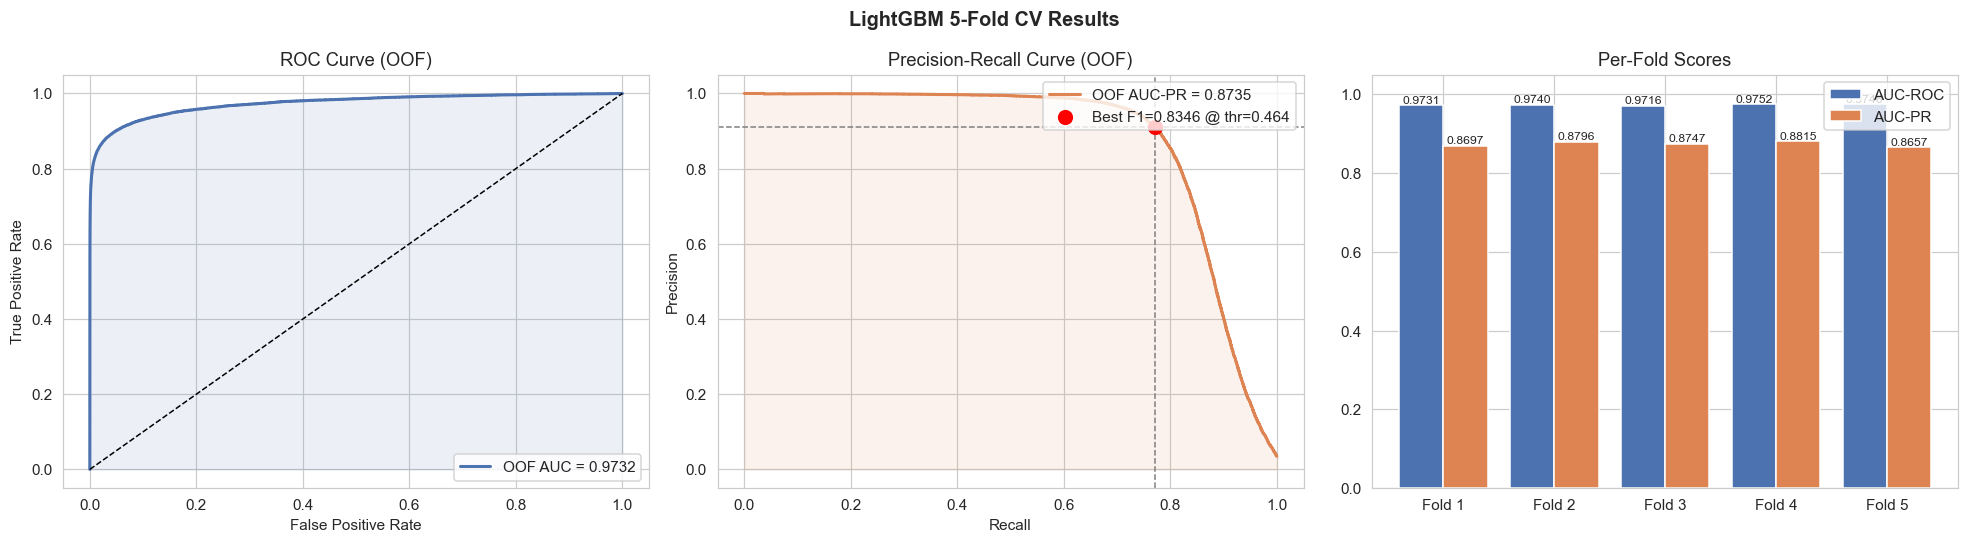

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. ROC Curve
ax = axes[0]
fpr, tpr, _ = roc_curve(y, oof_preds)
ax.plot(fpr, tpr, color='#4C72B0', lw=2, label=f'OOF AUC = {overall_auc:.4f}')
ax.plot([0,1],[0,1], 'k--', lw=1)
ax.fill_between(fpr, tpr, alpha=0.1, color='#4C72B0')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve (OOF)')
ax.legend(loc='lower right')

# 2. Precision-Recall Curve
ax = axes[1]
ax.plot(rec, prec, color='#DD8452', lw=2, label=f'OOF AUC-PR = {overall_apr:.4f}')
ax.axvline(rec[best_idx], color='gray', lw=1, linestyle='--')
ax.axhline(prec[best_idx], color='gray', lw=1, linestyle='--')
ax.scatter(rec[best_idx], prec[best_idx], color='red', s=80, zorder=5,
           label=f'Best F1={best_f1:.4f} @ thr={best_thr:.3f}')
ax.fill_between(rec, prec, alpha=0.1, color='#DD8452')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve (OOF)')
ax.legend(loc='upper right')

# 3. Fold scores
ax = axes[2]
x = np.arange(1, 6)
ax.bar(x - 0.2, scores_df['AUC-ROC'], width=0.4, label='AUC-ROC', color='#4C72B0')
ax.bar(x + 0.2, scores_df['AUC-PR'],  width=0.4, label='AUC-PR',  color='#DD8452')
ax.set_xticks(x); ax.set_xticklabels([f'Fold {i}' for i in x])
ax.set_ylim(0, 1.05)
ax.set_title('Per-Fold Scores')
ax.legend()
for i, (auc, apr) in enumerate(zip(scores_df['AUC-ROC'], scores_df['AUC-PR'])):
    ax.text(i+1-0.2, auc+0.005, f'{auc:.4f}', ha='center', fontsize=8)
    ax.text(i+1+0.2, apr+0.005, f'{apr:.4f}', ha='center', fontsize=8)

plt.suptitle('LightGBM 5-Fold CV Results', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5.2 OOF Prediction Distribution Analysis

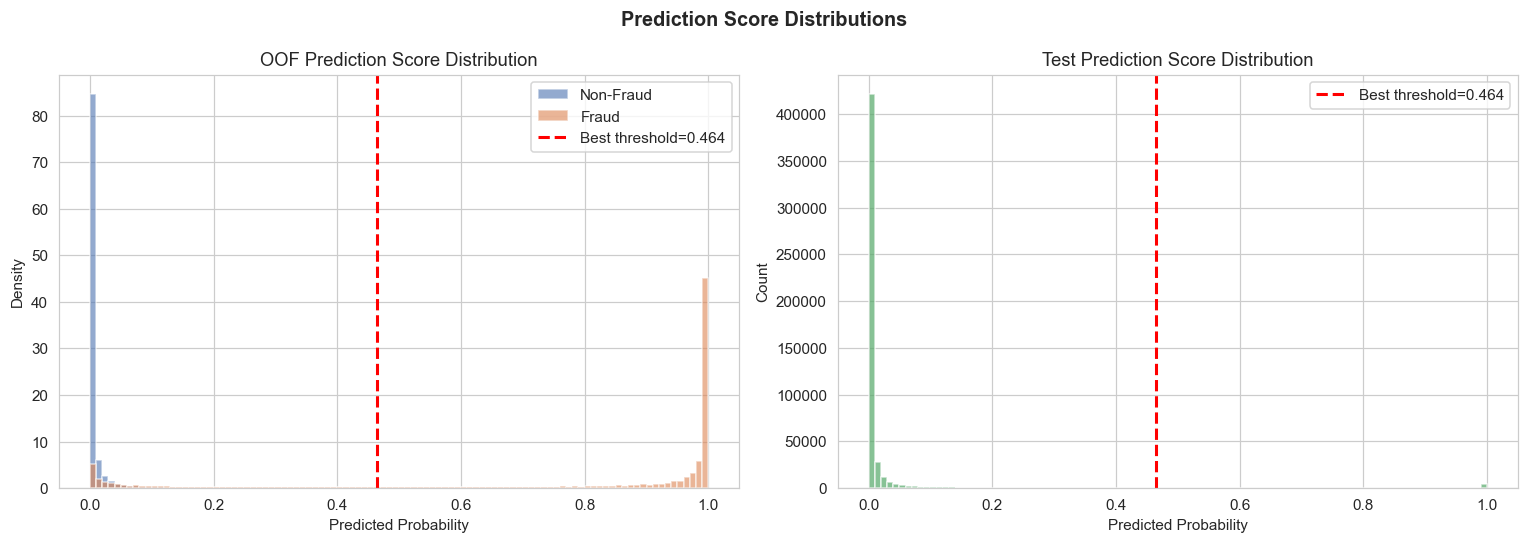

Estimated fraud in test set @ threshold 0.464: 10,485 (2.07%)


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# OOF Prediction Probability Distribution
ax = axes[0]
ax.hist(oof_preds[y == 0], bins=100, alpha=0.6, color='#4C72B0',
        label='Non-Fraud', density=True)
ax.hist(oof_preds[y == 1], bins=100, alpha=0.6, color='#DD8452',
        label='Fraud', density=True)
ax.axvline(best_thr, color='red', lw=2, linestyle='--', label=f'Best threshold={best_thr:.3f}')
ax.set_xlabel('Predicted Probability')
ax.set_ylabel('Density')
ax.set_title('OOF Prediction Score Distribution')
ax.legend()

# Test Prediction Probability Distribution
ax = axes[1]
ax.hist(test_preds, bins=100, color='#55A868', alpha=0.7)
ax.axvline(best_thr, color='red', lw=2, linestyle='--', label=f'Best threshold={best_thr:.3f}')
ax.set_xlabel('Predicted Probability')
ax.set_ylabel('Count')
ax.set_title('Test Prediction Score Distribution')
ax.legend()

plt.suptitle('Prediction Score Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

est_fraud = (test_preds >= best_thr).sum()
print(f'Estimated fraud in test set @ threshold {best_thr:.3f}: {est_fraud:,} ({est_fraud/len(test_preds)*100:.2f}%)')

---
# 6. Feature Importance & SHAP
---

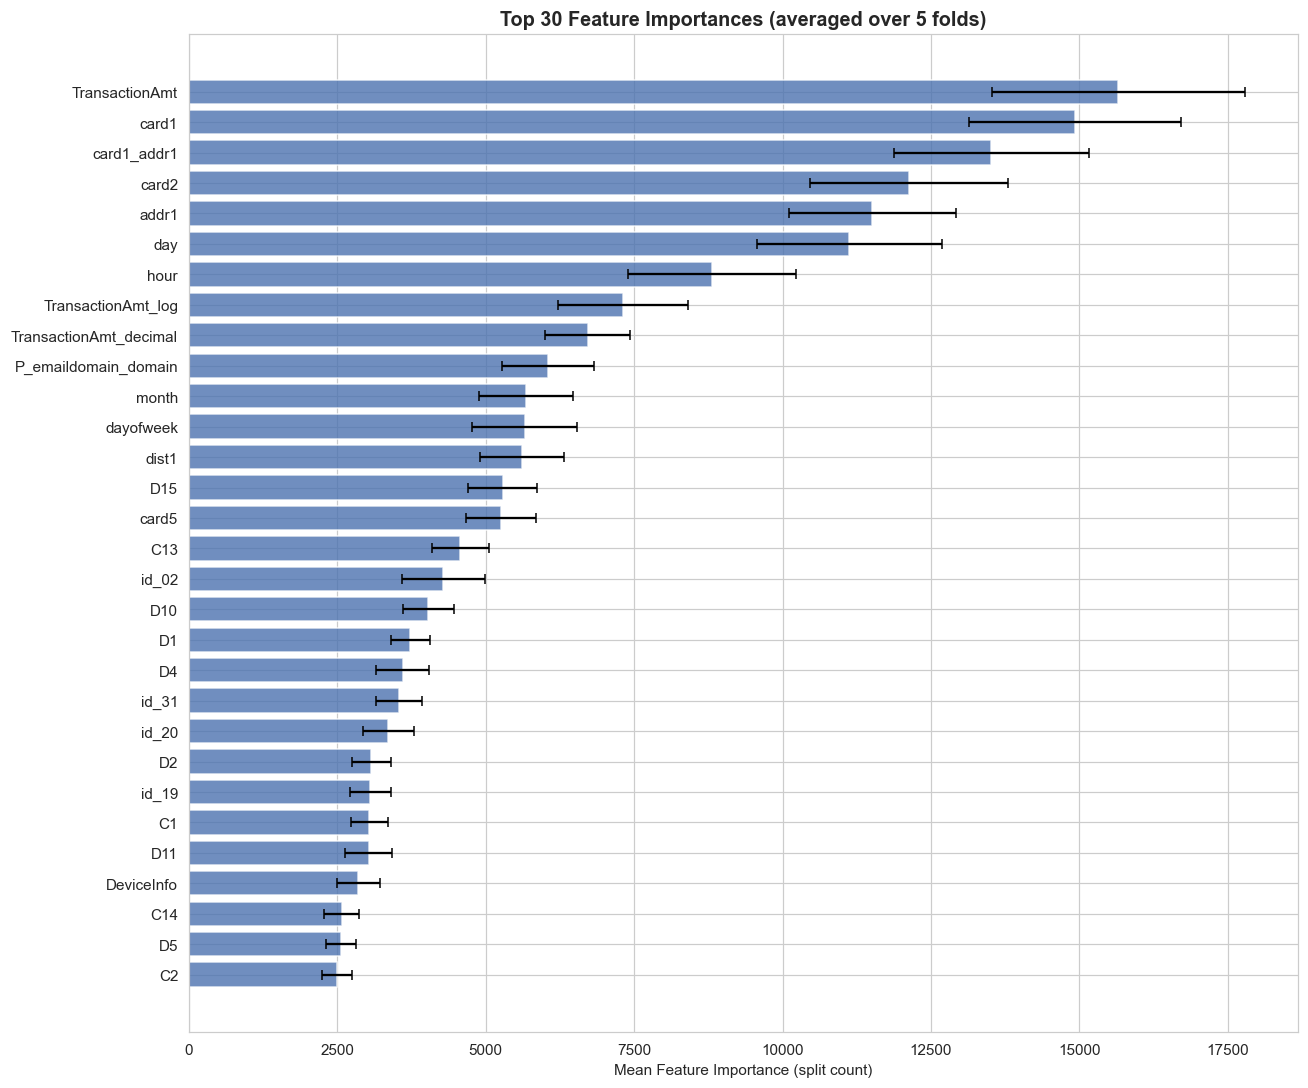

In [12]:
# Average feature importance across 5 folds
fi_cols = [f'fold{i}' for i in range(1, 6)]
feature_importances['importance_mean'] = feature_importances[fi_cols].mean(axis=1)
feature_importances['importance_std']  = feature_importances[fi_cols].std(axis=1)
fi_sorted = feature_importances.sort_values('importance_mean', ascending=False).head(30)

fig, ax = plt.subplots(figsize=(12, 10))
y_pos = np.arange(len(fi_sorted))
ax.barh(y_pos, fi_sorted['importance_mean'], xerr=fi_sorted['importance_std'],
        color='#4C72B0', alpha=0.8, edgecolor='white', capsize=3)
ax.set_yticks(y_pos)
ax.set_yticklabels(fi_sorted['feature'])
ax.invert_yaxis()
ax.set_xlabel('Mean Feature Importance (split count)')
ax.set_title('Top 30 Feature Importances (averaged over 5 folds)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
# SHAP — using the last fold's model on a 5,000-sample subset for speed
print('Computing SHAP values (this may take a minute)...')
sample_idx = X.sample(n=5000, random_state=SEED).index
X_sample = X.loc[sample_idx]

explainer = shap.TreeExplainer(model)  # model = last fold's model
shap_values = explainer.shap_values(X_sample)

# LightGBM binary: shap_values may be a list
if isinstance(shap_values, list):
    shap_vals = shap_values[1]
else:
    shap_vals = shap_values

print('SHAP values computed.')

Computing SHAP values (this may take a minute)...
SHAP values computed.


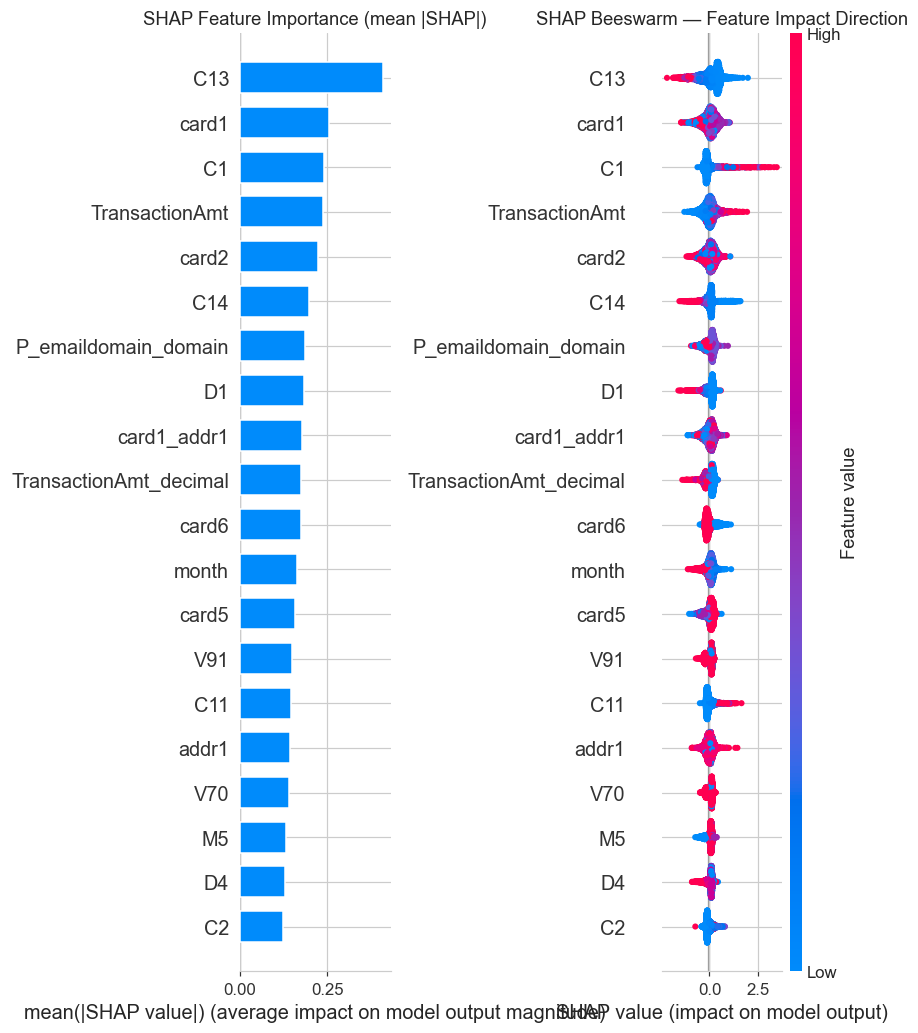

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

plt.sca(axes[0])
shap.summary_plot(shap_vals, X_sample, plot_type='bar',
                  max_display=20, show=False)
axes[0].set_title('SHAP Feature Importance (mean |SHAP|)', fontsize=12)

plt.sca(axes[1])
shap.summary_plot(shap_vals, X_sample,
                  max_display=20, show=False)
axes[1].set_title('SHAP Beeswarm — Feature Impact Direction', fontsize=12)

plt.tight_layout()
plt.show()

---
# 7. Results Summary
---

In [16]:
print('=' * 55)
print('   IEEE-CIS Fraud Detection — Pipeline Results')
print('=' * 55)
print(f'  Model             : LightGBM (5-Fold Stratified CV)')
print(f'  Total features    : {len(feature_cols)}')
print(f'  Train samples     : {len(X):,}')
print(f'  Test samples      : {len(X_test):,}')
print(f'  Fraud rate (train): {y.mean()*100:.2f}%')
print('-' * 55)
print(f'  OOF AUC-ROC  : {overall_auc:.5f}')
print(f'  OOF AUC-PR   : {overall_apr:.5f}')
print(f'  Best F1      : {best_f1:.5f}  @ threshold {best_thr:.4f}')
print(f'  Mean CV AUC  : {scores_df["AUC-ROC"].mean():.5f} ± {scores_df["AUC-ROC"].std():.5f}')
print('=' * 55)
print(f'  Submission   : submission_lgbm.csv')
print('=' * 55)

   IEEE-CIS Fraud Detection — Pipeline Results
  Model             : LightGBM (5-Fold Stratified CV)
  Total features    : 442
  Train samples     : 590,540
  Test samples      : 506,691
  Fraud rate (train): 3.50%
-------------------------------------------------------
  OOF AUC-ROC  : 0.97316
  OOF AUC-PR   : 0.87353
  Best F1      : 0.83459  @ threshold 0.4642
  Mean CV AUC  : 0.97368 ± 0.00142
  Submission   : submission_lgbm.csv


---
# 8. Model Export
---

Save all trained models and artifacts using `joblib` with `.joblib` extension.

In [17]:
# Convert string to a Path object
MODEL_DIR = Path('../../models') 

# Ensure the directory exists
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Save all 5 fold models
for i, fold_model in enumerate(models, 1):
    joblib.dump(fold_model, MODEL_DIR / f'ieee_lgbm_fold{i}.joblib')
    print(f'Saved ieee_lgbm_fold{i}.joblib')

# Save label encoders fitted on train+test combined
joblib.dump(label_encoders, MODEL_DIR / 'ieee_label_encoders.joblib')
print('Saved ieee_label_encoders.joblib')

# Save dropped high-missing columns list
joblib.dump(drop_cols, MODEL_DIR / 'ieee_drop_cols.joblib')
print('Saved ieee_drop_cols.joblib')

# Save threshold and feature list
joblib.dump(
    {'threshold': best_thr, 'features': feature_cols},
    MODEL_DIR / 'ieee_artifacts.joblib'
)
print(f'Saved ieee_artifacts.joblib  (threshold={best_thr:.4f})')

print(f'\nAll IEEE artifacts saved to {MODEL_DIR}')

Saved ieee_lgbm_fold1.joblib
Saved ieee_lgbm_fold2.joblib
Saved ieee_lgbm_fold3.joblib
Saved ieee_lgbm_fold4.joblib
Saved ieee_lgbm_fold5.joblib
Saved ieee_label_encoders.joblib
Saved ieee_drop_cols.joblib
Saved ieee_artifacts.joblib  (threshold=0.4642)

All IEEE artifacts saved to ../../models
